# **01. [Breast] Preparation and Data Analysis**

## **Introduction**

Preparation and Analysis of RHC-SP Breast Data for the Machine Learning Survival Study

## Environment Settings

In [ ]:
# download the file that contains the requirement management functions
!gdown 1563shEptjQS10FQbqjM-QsXot_cvHJBL --quiet
%run /content/bootstrap.py

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# put here the your Drive's path to the project
LOCAL_PROJECT_PATH = "/content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida"

set_project(LOCAL_PROJECT_PATH)
setup()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Projeto definido: /content/drive/MyDrive/Trabalho/Câncer/ML de Sobrevida

Grupos disponíveis:
1. data_analysis
2. ml
3. Criar novo grupo

Escolha (ex: 1,3): 1

Lendo dependências de data_analysis:
  - lifelines==0.30.3
  - matplotlib==3.10.0
  - numpy==2.0.2
  - pandas==2.2.2
  - plotly==5.24.1
  - scikit-learn==1.6.1
  - seaborn==0.13.2

 Instalando dependências necessárias:
 + scikit-learn==1.6.1

⚠️ Dependências instaladas.
Reiniciando o kernel automaticamente...


<IPython.core.display.Javascript object>

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

## Functions

In [ ]:
def data_prep(df, topogrup):
    """
    Prepares the dataset for analysis, applying necessary filters and transformations.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset to be prepared.
    topogrup : list
        List with the topography group codes to be selected.

    Returns:
    --------
    pandas.DataFrame
        The dataset after the transformations.

    """

    df_aux = df.copy()

    # TOPOGRUP - Filter by topography group
    df_aux = df_aux[df_aux.TOPOGRUP.isin(topogrup)]
    print(df_aux.shape)

    # AGE - Filter for age greater than 19
    df_aux = df_aux[df_aux.IDADE > 19]

    # SEX - Filter for female patients (SEXO == 2)
    df_aux = df_aux[df_aux.SEXO == 2]

    # UFRESID - Filter for residents of SP
    df_aux = df_aux[df_aux.UFRESID == 'SP']

    # ECGRUP - Remove records with ECGRUP equal to X or Y
    df_aux = df_aux[~df_aux.ECGRUP.isin(['X','Y'])]

    # ECGRUP Categorization - Categorize ECGRUP into 'In Situ', 'Inicial' and 'Avançado'
    df_aux['ECGRUP_CAT'] = ['In Situ' if ec == '0' else 'Inicial' if ec in ['I', 'II'] else 'Avançado' for ec in df_aux.ECGRUP]

    # ANODIAG - Filter for diagnosis year before 2020 (commented out)
    # df_aux = df_aux[df_aux.ANODIAG < 2020]

    # BASEDIAG - Filter for records with microscopic confirmation (BASEDIAG == 3)
    df_aux = df_aux[df_aux.BASEDIAG == 3]

    # TMO and TMOAPOS - Remove patients who underwent TMO and TMOAPOS
    df_aux = df_aux[df_aux.TMO == 0]
    df_aux = df_aux[df_aux.TMOAPOS == 0]

    # Date Columns - Convert to datetime objects
    list_datas = ['DTCONSULT', 'DTDIAG', 'DTTRAT', 'DTULTINFO']

    for col_data in list_datas:
        df_aux[col_data] = pd.to_datetime(df_aux[col_data])

    # Time Calculations - Calculate time differences in days
    df_aux['CONSDIAG'] = (df_aux.DTDIAG - df_aux.DTCONSULT).dt.days
    df_aux['DIAGTRAT'] = (df_aux.DTTRAT - df_aux.DTDIAG).dt.days
    df_aux['TRATCONS'] = (df_aux.DTTRAT - df_aux.DTCONSULT).dt.days
    df_aux['ULTIDIAG'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.days
    df_aux[['DIAGTRAT', 'TRATCONS']] = df_aux[['DIAGTRAT', 'TRATCONS']].fillna(-1)

    # Time Categories - Create categorical variables for time differences
    df_aux['CONSDIAG_CAT'] = [0 if consdiag <= 30 else 1 if consdiag <= 60 else 2 for consdiag in df_aux.CONSDIAG]
    df_aux['TRATCONS_CAT'] = [3 if tratcons < 0 else 0 if tratcons <= 60 else 1 if tratcons <= 90 else 2 for tratcons in df_aux.TRATCONS]
    df_aux['DIAGTRAT_CAT'] = [3 if diagtrat < 0 else 0 if diagtrat <= 60 else 1 if diagtrat <= 90 else 2 for diagtrat in df_aux.DIAGTRAT]

    # Recurrence Presence - Create a variable for presence of recurrence (0 = No, 1 = Yes)
    df_aux['PRESENCA_REC'] = [0 if rec == 1 else 1 for rec in df_aux.RECNENHUM]
    df_aux.loc[(df_aux.PRESENCA_REC == 0) & (df_aux.DTRECIDIVA.notnull()), 'PRESENCA_REC'] = 1

    # Metastasis Presence - Create a column indicating the presence of metastasis
    df_aux['PRESENCA_META'] = 0
    df_aux.loc[df_aux.META01.notnull(), 'PRESENCA_META'] = 1

    # DRS - Extract DRS number
    DRS_expand = df_aux.DRS.str.split(' ', expand=True)
    df_aux['DRS'] = DRS_expand[1]

    # DRS_INST - Extract DRS_INST number
    DRS_expand = df_aux.DRS_INST.str.split(' ', expand=True)
    df_aux['DRS_INST'] = DRS_expand[1]

    # Outcome Variables - Create outcome variables (overall survival, cancer-specific survival, and survival at 1, 3, 5, 7 and 10 years)
    df_aux['obito_geral'] = 0
    df_aux['obito_cancer'] = 0

    df_aux['sobrevida_ano1'] = 0
    df_aux['sobrevida_ano3'] = 0
    df_aux['sobrevida_ano5'] = 0
    df_aux['sobrevida_ano7'] = 0
    df_aux['sobrevida_ano10'] = 0

    df_aux.loc[df_aux.ULTINFO > 2, 'obito_geral'] = 1
    df_aux.loc[df_aux.ULTINFO == 3, 'obito_cancer'] = 1

    df_aux.loc[df_aux.ULTIDIAG > 365.25, 'sobrevida_ano1'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 3*365.25, 'sobrevida_ano3'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 5*365.25, 'sobrevida_ano5'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 7*365.25, 'sobrevida_ano7'] = 1
    df_aux.loc[df_aux.ULTIDIAG > 10*365.25, 'sobrevida_ano10'] = 1

    # Drop Unused Columns - Remove columns that will not be used in the analysis
    cols = df_aux.columns
    drop_cols = ['UFNASC', 'UFRESID', 'CIDADE', 'DTCONSULT', 'CLINICA', 'DTDIAG',
                 'BASEDIAG', 'TOPOGRUP', 'DESCTOPO', 'DESCMORFO', 'T', 'N', 'M',
                 'PT', 'PN', 'PM', 'S', 'G', 'PSA', 'GLEASON', 'LOCALTNM',
                 'IDMITOTIC', 'OUTRACLA', 'META01', 'META02', 'META03', 'META04',
                 'DTTRAT', 'NAOTRAT', 'TRATAMENTO', 'TRATHOSP', 'TRATFANTES',
                 'TRATFAPOS', 'NENHUMANT', 'CIRURANT', 'RADIOANT', 'QUIMIOANT',
                 'HORMOANT', 'TMOANT', 'IMUNOANT', 'OUTROANT', 'DTULTINFO',
                 'CICI', 'CICIGRUP', 'CICISUBGRU', 'FAIXAETAR', 'LATERALI',
                 'INSTORIG', 'PERDASEG', 'ERRO', 'DTRECIDIVA', 'RECNENHUM',
                 'RECLOCAL', 'RECREGIO', 'RECDIST', 'REC01', 'REC02', 'REC03',
                 'REC04', 'CIDO', 'DSCCIDO', 'HABILIT', 'HABIT11', 'HABILIT1',
                 'CIDADEH', 'CIDADE_INS', 'TMO', 'TMOAPOS', 'SEXO']

    cols = cols.drop(drop_cols)

    return df_aux[cols]

# **Data Preparation**

Step responsible for organizing, cleaning, and transforming raw data into a format suitable for analysis and modeling.

In [ ]:
# Database - Set/2024
!gdown 1_CGn_150mpmfxwsyVyB5LTeqeAVgJKhB --quiet

In [ ]:
# Load Data and Display Information
df = pd.read_csv('pacigeral_set24.csv') # Load the CSV file into a Pandas DataFrame
print(df.shape) # Print the dimensions of the DataFrame (rows, columns)
df.head(3) # Display the first 3 rows of the DataFrame

/tmp/ipykernel_1517/554014987.py:2: DtypeWarning: Columns (24,25,26,33,37,79,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('pacigeral_set24.csv') # Load the CSV file into a Pandas DataFrame


(1233793, 105)


,INSTITU,ESCOLARI,IDADE,SEXO,UFNASC,UFRESID,IBGE,CIDADE,CATEATEND,DTCONSULT,...,CIDO,DSCCIDO,HABILIT,HABIT11,HABILIT1,HABILIT2,CIDADEH,DRS_INST,RRAS_INST,CIDADE_INS
0,14,4,49,2,SC,SC,4209409,LAGUNA,9,2011-03-23,...,81603.0,COLANGIOCARCINOMA,14,Inativo,6,5,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
1,8672,9,54,1,SP,SP,3550308,SAO PAULO,9,2006-05-30,...,80903.0,CARCINOMA BASOCELULAR SOE,7,CACON com Serviço de Oncologia Pediátrica,3,2,São Paulo,DRS 01 Grande Sao Paulo,RRAS 06,SAO PAULO
2,19100,9,77,1,SP,SP,3504503,AVARE,9,2003-12-14,...,82113.0,ADENOCARCINOMA TUBULAR,14,Inativo,6,5,Avaré,DRS 06 Bauru,RRAS 09,AVARE


In [ ]:
# Prepare Data for Breast Cancer Analysis
df_mama = data_prep(df, ['C50']) # Prepare the data, filtering for cervical cancer (ICD-10 code 'C50')

print(df_mama.shape) # Print the shape (rows, columns) of the filtered DataFrame
df_mama.head(3) # Display the first 3 rows of the filtered DataFrame

(170413, 105)
(155010, 50)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,DIAGTRAT_CAT,PRESENCA_REC,PRESENCA_META,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10
16,8,4,65,3505708,9,1,C509,85003,I,I,...,0,1,0,0,0,1,1,1,1,1
22,8,9,44,3550308,9,2,C501,85003,IIA,II,...,2,1,0,1,1,1,1,1,1,1
24,8,4,46,3550308,9,2,C506,85003,IIA,II,...,2,0,0,0,0,1,1,1,1,1


In [ ]:
# Columns
df_mama.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_REC', 'PRESENCA_META', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
       'sobrevida_ano10'],
      dtype='object')

**Information**

In [ ]:
# Calculate and Adjust Survival Time in Months
df_mama['meses_diag'] = np.ceil(df_mama['ULTIDIAG']/30).astype(int) # Calculate survival time in months, rounding up

df_mama.loc[df_mama.meses_diag == 0, 'meses_diag'] = 1 # Ensure no survival time is zero (set to 1 month)
df_mama.loc[df_mama.meses_diag > 120, ['meses_diag', 'obito_geral']] = [121, 0] # Cap survival time at 61 months and set obito_geral to 0 for those exceeding the cap.

df_mama.meses_diag.value_counts().sort_index().tail() # Display the value counts for the last few survival times (for checking)

,count
meses_diag,
117,521
118,500
119,479
120,548
121,29591


**General columns**

In [ ]:
df_mama.NENHUM.value_counts().sort_index()

,count
NENHUM,
0,151550
1,3460


**Outputs**

In [ ]:
ano = df_mama[~((df_mama.obito_geral == 0) & (df_mama.sobrevida_ano5 == 0))]
print(ano.shape)
ano.sobrevida_ano5.value_counts().sort_index()

(105774, 51)


,count
sobrevida_ano5,
0,35202
1,70572


**Morphology**

In [ ]:
df_mama[df_mama['MORFO'].astype(str).str.endswith('2')].shape

(13196, 50)

In [ ]:
df_mama[df_mama['MORFO'].astype(str).str.endswith('3')].shape

(141814, 50)

In [ ]:
print(np.sort(df_mama[df_mama['MORFO'].astype(str).str.endswith('2')].MORFO.unique()))

[80102 80502 80702 80762 81402 82012 82302 82632 85002 85012 85032 85042
 85072 85202 85222]


**Morphologies with beginning = 9**

In [ ]:
df_mama[df_mama.MORFO.isin([90703])]['MORFO'].value_counts().sort_index()

,count
MORFO,
90703,1


In [ ]:
df_mama[df_mama.MORFO.isin([90703])].index

Index([1221185], dtype='int64')

In [ ]:
df_morfo_inicio9 = df.loc[df_mama[df_mama.MORFO.isin([90703])].index]
df_morfo_inicio9.shape

(1, 105)

In [ ]:
df_morfo_inicio9.to_csv('mama_morfo_inicio9.csv', index=False)

**Morphologies with ending = 2**

In [ ]:
df_sem_insitu = df_mama[df_mama.ECGRUP_CAT != 'In Situ']

df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].shape

(649, 51)

In [ ]:
df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].index

Index([  80074,   87149,   88634,   89740,   91015,   91063,   91075,   91081,
         91101,   91282,
       ...
       1192422, 1193028, 1193122, 1203400, 1203475, 1203921, 1203952, 1211075,
       1212741, 1229006],
      dtype='int64', length=649)

In [ ]:
df_morfo_final2 = df.loc[df_sem_insitu[df_sem_insitu['MORFO'].astype(str).str.endswith('2')].index]
df_morfo_final2.shape

(649, 105)

In [ ]:
df_morfo_final2.to_csv('mama_morfo_final2.csv', index=False)

**Saving the database into a csv file**

In [ ]:
# Saving database
df_mama.to_csv('mama.csv', index=False)

## **Input ESCOLARI**

**KNNImputer**

In [ ]:
# df_mama.ESCOLARI.value_counts(normalize=True).sort_index()

,proportion
ESCOLARI,
1,0.034011
2,0.233946
3,0.157454
4,0.182033
5,0.115902
9,0.276653


In [ ]:
# escolari = df_mama[df_mama.ESCOLARI != 9]
# escolari.ESCOLARI.value_counts().sort_index()

,count
ESCOLARI,
1,5272
2,36264
3,24407
4,28217
5,17966


In [ ]:
# from sklearn.impute import KNNImputer
# from sklearn.preprocessing import MinMaxScaler

# # Input da ESCOLARI usando ECGRUP, IDADE e SEXO
# cols_input = ['ESCOLARI', 'IDADE', 'ECGRUP', 'CATEATEND']

# df_esc = df_mama[cols_input].copy()
# df_esc.loc[df_esc.ESCOLARI == 9, 'ESCOLARI'] = np.nan
# df_esc.loc[df_esc.ECGRUP == 'I', 'ECGRUP'] = 1
# df_esc.loc[df_esc.ECGRUP == 'II', 'ECGRUP'] = 2
# df_esc.loc[df_esc.ECGRUP == 'III', 'ECGRUP'] = 3
# df_esc.loc[df_esc.ECGRUP == 'IV', 'ECGRUP'] = 4

# X = df_esc.values
# mms = MinMaxScaler()
# X[:, 1:] = mms.fit_transform(X[:, 1:])

# imputer = KNNImputer(n_neighbors=1, weights='distance')
# df_mama['ESCOLARI_PREENCH'] = imputer.fit_transform(X)[:,0].round()

# df_mama.ESCOLARI_PREENCH.value_counts().sort_index()

,count
ESCOLARI_PREENCH,
1.0,6747
2.0,43126
3.0,28646
4.0,42823
5.0,33668


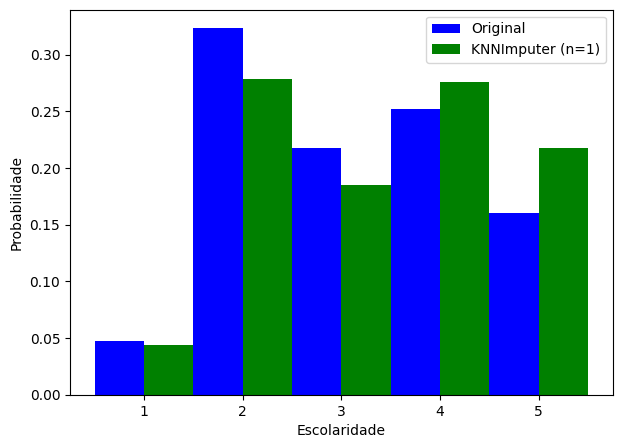

In [ ]:
# x = np.sort(escolari.ESCOLARI.unique())
# inic = escolari.ESCOLARI.value_counts().sort_index().values/escolari.shape[0]
# knn1 = df_mama.ESCOLARI_PREENCH.value_counts().sort_index().values/df_mama.shape[0]

# plt.figure(figsize=(7, 5))
# plt.bar(x - 0.25, inic, color = 'b', width = 0.5, label='Original')
# plt.bar(x + 0.25, knn1, color = 'g', width = 0.5, label='KNNImputer (n=1)')
# plt.ylabel("Probabilidade")
# plt.xlabel("Escolaridade")
# plt.legend()

# plt.show()

In [ ]:
# from scipy.stats import ks_2samp

# # Realize o teste de Kolmogorov-Smirnov
# statistic, p_value = ks_2samp(escolari.ESCOLARI, df_mama.ESCOLARI_PREENCH)

# # Exiba o resultado do teste
# print('Estatística de teste:', statistic)
# print('p-value:', p_value)

# # Verifique se a diferença entre as distribuições é significativa
# alpha = 0.05
# if p_value > alpha:
#     print('\nNão há evidências para rejeitar a hipótese nula (as distribuições são similares)')
# else:
#     print('\nRejeitamos a hipótese nula (as distribuições são diferentes)')

Estatística de teste: 0.0815736427128565
p-value: 0.0

Rejeitamos a hipótese nula (as distribuições são diferentes)


# **Data Exploration**

Initial analysis process to understand the structure, distribution, and patterns within the data.

## **Data**

In [ ]:
# Breast Dataset
!gdown 11kKWTMoCH-m7U3n5CNrZbBs2zVePdciU --quiet

In [ ]:
df = pd.read_csv('mama.csv')
print(df.shape)
df.head(3)

(155010, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag
0,8,4,65,3505708,9,1,C509,85003,I,I,...,1,0,0,0,1,1,1,1,1,121
1,8,9,44,3550308,9,2,C501,85003,IIA,II,...,1,0,0,1,1,1,1,1,1,121
2,8,4,46,3550308,9,2,C506,85003,IIA,II,...,0,0,0,0,1,1,1,1,1,121


In [ ]:
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_REC', 'PRESENCA_META', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
       'sobrevida_ano10', 'meses_diag'],
      dtype='object')

### **Cases and deaths**

In [ ]:
# Columns
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_REC', 'PRESENCA_META', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
       'sobrevida_ano10', 'meses_diag'],
      dtype='object')

In [ ]:
# Exclude patients with EC = 0 (In Situ)
df_mama = df[df.ECGRUP_CAT != 'In Situ']

# Exclude patients with morphology ending in 2
df_mama = df_mama[~df_mama['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df_mama = df_mama[~df_mama.MORFO.isin([90703])]

df_mama.shape

(141727, 51)

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df_mama.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death counts to the DataFrame ---
# Calculate total deaths by grouping by diagnosis year and summing 'obito_geral' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito'] = df_mama.groupby('ANODIAG').obito_geral.sum()

In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito'],                  # Death counts on y-axis
    name="Deaths",                   # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Breast Cancer",      # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',          # Show every year
        tick0=2000,                 # First tick at year 2000
        dtick=1,                    # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

In [ ]:
# --- Calculate total cases per diagnosis year ---
# Extract 'ANODIAG' column, count occurrences per year, and sort by year index
ano = df_mama.ANODIAG.value_counts().sort_index()

# Convert Series to DataFrame for structural consistency
ano = pd.DataFrame(ano)

# --- Add death y cancer counts to the DataFrame ---
# Calculate total deaths by cancer by grouping by diagnosis year and summing 'obito_cancer' (death indicator)
# The index alignment ensures matching with existing 'ano' index
ano['obito_cancer'] = df_mama.groupby('ANODIAG').obito_cancer.sum()
ano

,count,obito_cancer
ANODIAG,,
2000,3480,1410
2001,3558,1381
2002,4280,1554
2003,4440,1558
2004,4533,1519
2005,4647,1607
2006,4553,1484
2007,4624,1472
2008,5178,1683


In [ ]:
# Import Plotly's graph objects module for advanced visualizations
import plotly.graph_objects as go

# Initialize a blank Figure object
fig = go.Figure()

# Background layer: Total cases (with reduced opacity for visibility)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['count'],                  # Total case counts on y-axis
    name="Total cases",              # Legend label
    marker_color='blue',             # Base color for total cases
    opacity=0.6                      # Partial transparency for overlay effect
))

# Foreground layer: Deaths (more opaque for emphasis)
fig.add_trace(go.Bar(
    x=ano.index,                     # Diagnosis years on x-axis
    y=ano['obito_cancer'],           # Death counts on y-axis
    name="Deaths by cancer",         # Legend label
    marker_color='red',              # Highlight color for deaths
    opacity=0.8                      # Higher opacity for visual prominence
))

# Critical layout configuration for proper overlay
fig.update_layout(
    barmode='overlay',               # Overlap bars instead of stacking
    title_text="Breast Cancer",      # Chart title
    xaxis_tickangle=-45,             # Rotate x-axis labels for readability
    xaxis=dict(
        tickmode='linear',           # Show every year
        tick0=2000,                  # First tick at year 2000
        dtick=1,                     # Tick interval = 1 year
        title_text="Year of diagnosis"  # X-axis label (fixed typo)
    ),
    yaxis=dict(
        title_text="Number of patients"  # Y-axis label
    )
)

# Display the interactive visualization
fig.show()

## **Kaplan-Meier Curves**

**Topografias**

In [ ]:
df.TOPO.value_counts().sort_index()

,count
TOPO,
C500,4983
C501,7281
C502,9786
C503,5734
C504,38118
C505,6951
C506,1402
C508,24300
C509,56455


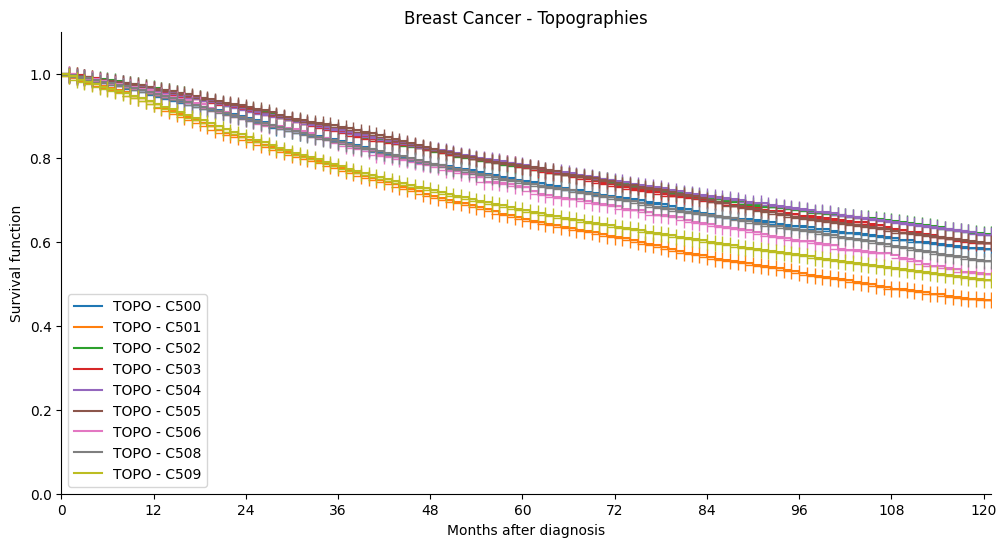

In [ ]:
topos = np.sort(df.TOPO.unique())

E = (df.obito_geral == 1)
T = df.meses_diag
title = 'Breast Cancer - Topographies'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

for topo in topos:
    group = (df.TOPO == f'{topo}')
    label = f'TOPO - {topo}'

    T1=T[group]
    E1=E[group]

    ax = kmf.fit(T1, E1, label=f"{label}").plot(ax=ax, ci_show=False,
                                                show_censors=True)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121])
plt.show()

**EC e Habilit2**

In [ ]:
df.ECGRUP_CAT.value_counts().sort_index()

,count
ECGRUP_CAT,
Avançado,53086
In Situ,12633
Inicial,89291


In [ ]:
df.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
0,12633
I,34090
II,55201
III,38334
IV,14752


In [ ]:
df.HABILIT2.value_counts().sort_index()

,count
HABILIT2,
1,75669
2,71442
3,158
4,2735
5,5006


In [ ]:
df_habilit = df[df.HABILIT2.isin([1, 2, 3])]
print(df_habilit.shape)
df_habilit.HABILIT2.value_counts().sort_index()

(147269, 51)


,count
HABILIT2,
1,75669
2,71442
3,158


In [ ]:
df_habilit.ECGRUP.value_counts().sort_index()

,count
ECGRUP,
0,11758
I,31660
II,52530
III,37041
IV,14280


In [ ]:
df_ec1 = df_habilit[df_habilit.ECGRUP == 'I']
df_ec2 = df_habilit[df_habilit.ECGRUP == 'II']
df_ec3 = df_habilit[df_habilit.ECGRUP == 'III']
df_ec4 = df_habilit[df_habilit.ECGRUP == 'IV']

df_ec1.shape, df_ec2.shape, df_ec3.shape, df_ec4.shape

((31660, 51), (52530, 51), (37041, 51), (14280, 51))

log-rank p-value:
    CACON com UNACON = 5.48e-05
    CACON com Hosp. Geral = 0.05319



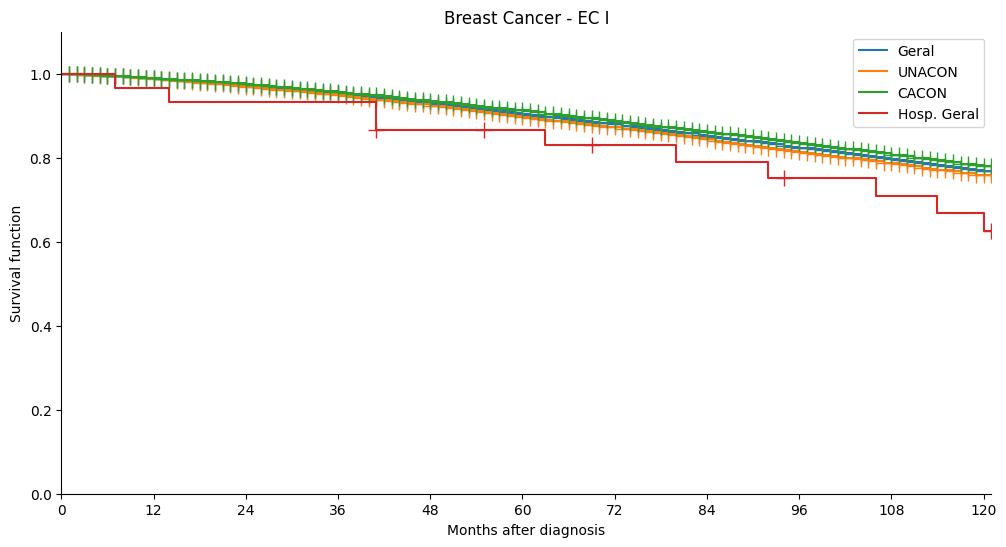

In [ ]:
data = df_ec1

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Breast Cancer - EC I'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 2.178e-15
    CACON com Hosp. Geral = 0.25



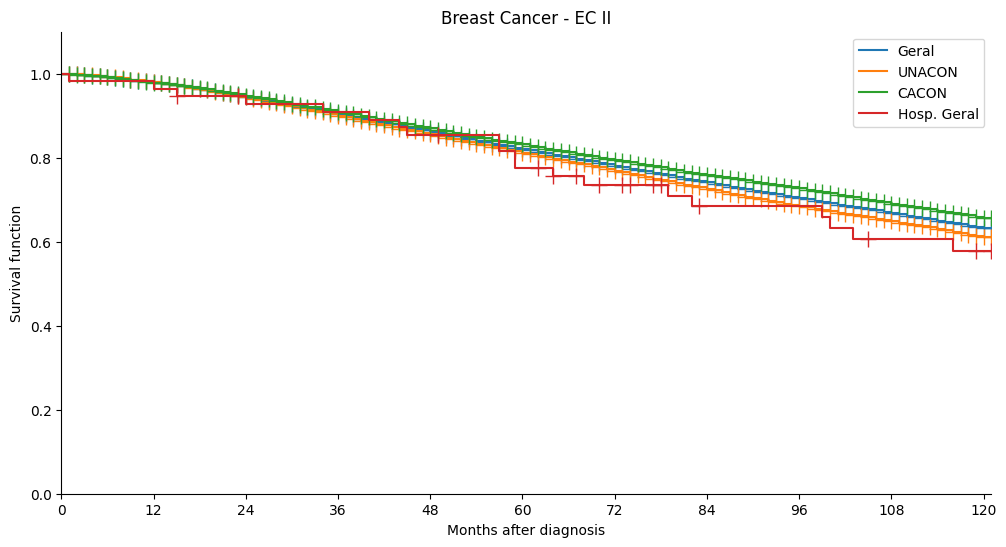

In [ ]:
data = df_ec2

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Breast Cancer - EC II'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 6.784e-18
    CACON com Hosp. Geral = 0.01635



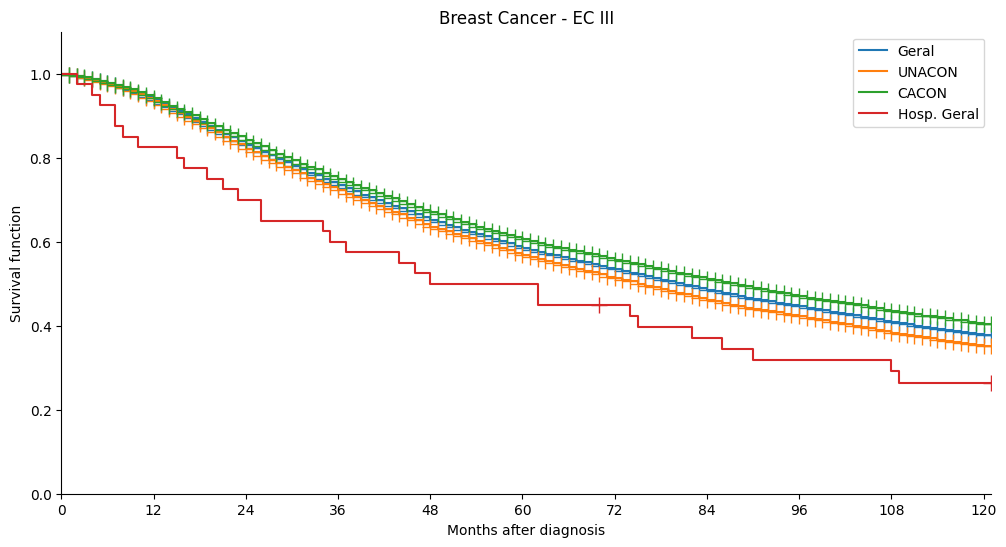

In [ ]:
data = df_ec3

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Breast Cancer - EC III'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

log-rank p-value:
    CACON com UNACON = 0.008162
    CACON com Hosp. Geral = 0.494



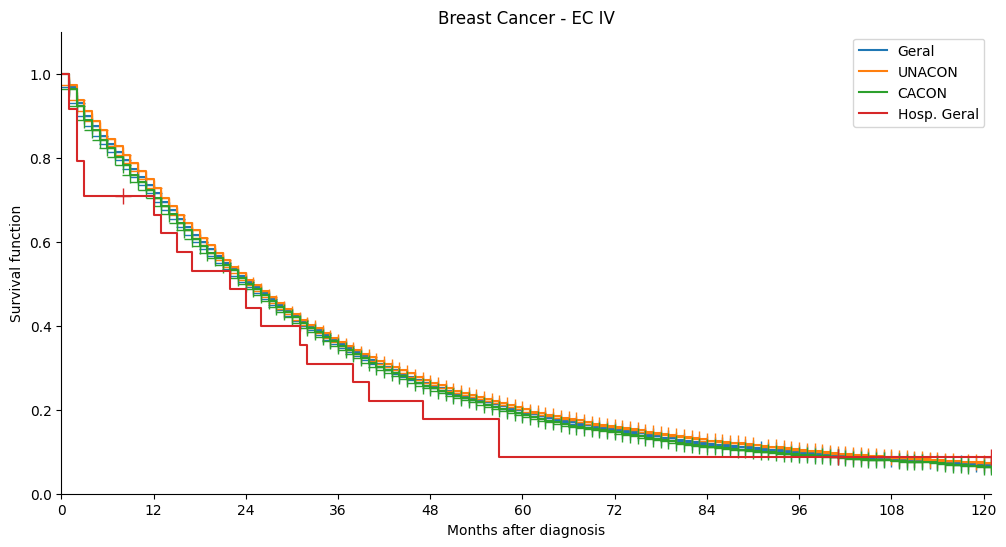

In [ ]:
data = df_ec4

E = (data.obito_geral == 1)
T = data.meses_diag
title = 'Breast Cancer - EC IV'

kmf = KaplanMeierFitter()

fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)
ax = kmf.fit(T, E, label=f'Geral').plot(ax=ax, ci_show=False, show_censors=True)

group1 = (data.HABILIT2 == 1)
label1 = 'UNACON'
T1=T[group1]
E1=E[group1]

group2 = (data.HABILIT2 == 2)
label2 = 'CACON'
T2=T[group2]
E2=E[group2]

group3 = (data.HABILIT2 == 3)
label3 = 'Hosp. Geral'
T3=T[group3]
E3=E[group3]

ax = kmf.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)

results1 = logrank_test(T2, T1, event_observed_A=E2, event_observed_B=E1)
results2 = logrank_test(T2, T3, event_observed_A=E2, event_observed_B=E3)

ax.set_title(title)
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121]);

print('log-rank p-value:')
print(f'    CACON com UNACON = {results1.p_value:.4}')
print(f'    CACON com Hosp. Geral = {results2.p_value:.4}')
print()

**DRS**

In [ ]:
df.DRS.value_counts().sort_index()

,count
DRS,
1,74083
2,3908
3,3535
4,5133
5,3210
6,8272
7,13633
8,1798
9,5303


In [ ]:
results_drs = pd.DataFrame(columns=['DRS', 'Total', 'Inicial', 'Avançado',
                                    'mean', 'min', '25%', '50%', '75%', 'max'])

list_drs = np.sort(df.DRS.unique())

for n_drs in list_drs:

    df_drs = df[df.DRS == n_drs]

    n = df_drs.shape[0]
    ini = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_drs.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_drs.obito_geral == 1)
    T = df_drs.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min',
                                                               '25%', '50%',
                                                               '75%', 'max']].values[0]

    new = {'DRS': n_drs, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_drs = pd.concat([results_drs, pd.DataFrame([new])], ignore_index=True)

results_drs

<ipython-input-41-18d5c059dccb>:27: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,DRS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,1,74083,0.567850,0.338242,0.737422,0.534018,0.616169,0.719297,0.849487,1.0
1,2,3908,0.557318,0.348772,0.781164,0.621695,0.684186,0.758535,0.872710,1.0
2,3,3535,0.600000,0.346252,0.745332,0.560315,0.630364,0.725564,0.850188,1.0
3,4,5133,0.664329,0.272745,0.790820,0.600586,0.684396,0.781699,0.888755,1.0
4,5,3210,0.536137,0.309034,0.788782,0.638913,0.707731,0.771650,0.863132,1.0
5,6,8272,0.588612,0.343448,0.743493,0.571461,0.639250,0.720290,0.838338,1.0
6,7,13633,0.565099,0.363310,0.746743,0.550740,0.628298,0.725545,0.855553,1.0
7,8,1798,0.547275,0.382091,0.753776,0.583466,0.647635,0.723300,0.858264,1.0
8,9,5303,0.607769,0.336036,0.738115,0.556739,0.624972,0.712524,0.838781,1.0
9,10,5908,0.625592,0.309919,0.753669,0.566790,0.640931,0.729314,0.859607,1.0


In [ ]:
def plot_km_drs(df, n_drs):

    data = df[df.DRS == n_drs]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Breast Cancer - DRS {n_drs}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E, #label=f'DRS {n_drs}'
    ).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Months after diagnosis')
    ax.set_ylabel('Survival function')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 132, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 121]);

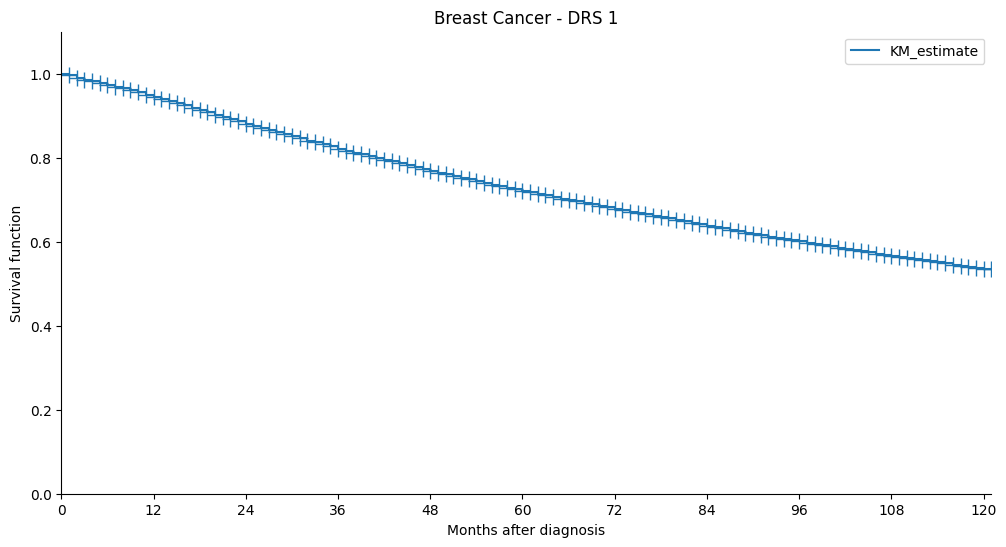

In [ ]:
plot_km_drs(df, 1)

In [ ]:
results_drs.to_csv('results_drs.csv', index=False)

**RRAS**

In [ ]:
df.RRAS.value_counts().sort_index()

,count
RRAS,
RRAS 01,7396
RRAS 02,7029
RRAS 03,1052
RRAS 04,3059
RRAS 05,5624
RRAS 06,49923
RRAS 07,5557
RRAS 08,5226
RRAS 09,8272


In [ ]:
results_rras = pd.DataFrame(columns=['RRAS', 'Total', 'Inicial', 'Avançado',
                                     'mean', 'min', '25%', '50%', '75%', 'max'])

list_rras = np.sort(df.RRAS.unique())

for n_rras in list_rras:

    df_rras = df[df.RRAS == n_rras]

    n = df_rras.shape[0]
    ini = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Inicial']
    avanc = df_rras.ECGRUP_CAT.value_counts(normalize=True).sort_index()['Avançado']

    E = (df_rras.obito_geral == 1)
    T = df_rras.meses_diag

    kmf = KaplanMeierFitter()

    surv_info = kmf.fit(T, E).survival_function_.describe().T[['mean', 'min',
                                                               '25%', '50%',
                                                               '75%', 'max']].values[0]

    new = {'RRAS': n_rras, 'Total': n, 'Inicial': ini, 'Avançado': avanc,
           'mean': surv_info[0], 'min': surv_info[1], '25%': surv_info[2],
           '50%': surv_info[3], '75%': surv_info[4], 'max': surv_info[5]}

    results_rras = pd.concat([results_rras, pd.DataFrame([new])], ignore_index=True)

results_rras

<ipython-input-46-4a5a66a9c5e8>:27: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,RRAS,Total,Inicial,Avançado,mean,min,25%,50%,75%,max
0,RRAS 01,7396,0.587209,0.333559,0.765663,0.567622,0.649738,0.751828,0.876676,1.0
1,RRAS 02,7029,0.546024,0.384407,0.725599,0.511664,0.595136,0.710395,0.839524,1.0
2,RRAS 03,1052,0.496198,0.437262,0.684543,0.413431,0.532918,0.659492,0.837592,1.0
3,RRAS 04,3059,0.531546,0.379536,0.709336,0.495329,0.576528,0.687232,0.830754,1.0
4,RRAS 05,5624,0.535740,0.385491,0.704998,0.482424,0.564500,0.687844,0.827077,1.0
5,RRAS 06,49923,0.575406,0.322497,0.741032,0.541716,0.623279,0.722445,0.850797,1.0
6,RRAS 07,5557,0.656649,0.280547,0.786292,0.593927,0.676408,0.776865,0.888310,1.0
7,RRAS 08,5226,0.553961,0.401072,0.742901,0.556941,0.622583,0.722091,0.853984,1.0
8,RRAS 09,8272,0.588612,0.343448,0.743493,0.571461,0.639250,0.720290,0.838338,1.0
9,RRAS 10,5303,0.607769,0.336036,0.738115,0.556739,0.624972,0.712524,0.838781,1.0


In [ ]:
def plot_km_rras(df, n_rras):

    data = df[df.RRAS == n_rras]

    E = (data.obito_geral == 1)
    T = data.meses_diag
    title = f'Breast Cancer - {n_rras}'

    kmf = KaplanMeierFitter()

    fig = plt.figure(figsize=(12, 6))
    ax = plt.subplot(111)
    ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)

    ax.set_title(title)
    ax.set_xlabel('Months after diagnosis')
    ax.set_ylabel('Survival function')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 132, 12))
    plt.ylim([0, 1.1])
    plt.xlim([0, 121]);

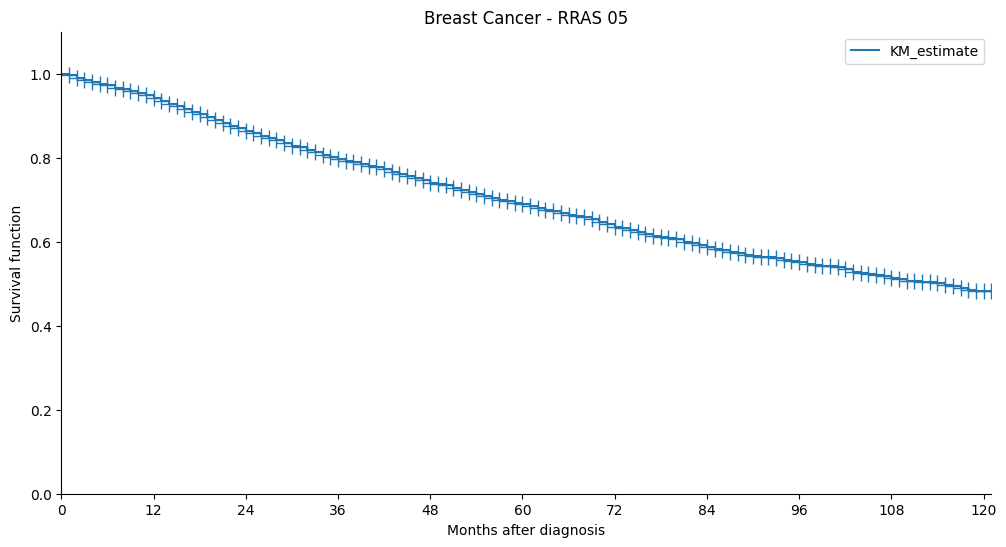

In [ ]:
plot_km_rras(df, 'RRAS 05')

In [ ]:
results_rras.to_csv('results_rras.csv', index=False)

# **Results**

### Selections made:
- Age greater than 19 years;
- Only female patients;
- State of residence in São Paulo;
- Clinical staging categorized as I, II, III, or IV (excluding in situ cases);
- Patients with microscopic confirmation;
- Patients who did not undergo bone marrow transplantation;
- Topography categorized as ICD-10 C50.

### Initial Database size:
1233793 pacients
### Final database size:
155010 pacients


## Requirements Synchronization

In [ ]:
sync("data_analysis", ["seaborn", "plotly", "scikit-learn", "lifelines"])